In [54]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 


# Function to standardise factors across all stocks
- assuming factor's datasets can be approximated to a normal distribution, and thus can be standardised, this is function to standardise factors later

In [63]:
def standardise(factor):
    return (factor - factor.mean())/factor.std()

# Load Data
- Get data and returns

In [56]:
#get data and returns
tickers = ["PLY.AX", "LAU.AX", "TLX.AX", "COS.AX", "ANG.AX", "VVA.AX", "WTC.AX", "AUB.AX", "XYZ.AX", "DUG.AX"]
data = yf.download(tickers, start ="2024-01-01", end = "2025-12-31")
returns = data["Close"].pct_change()
#missing XYZ.AX data
data["Close"] = data["Close"].ffill()
data["Volume"] = data["Volume"].fillna(0)
returns = data["Close"].pct_change()
returns = returns.replace([np.inf, -np.inf], np.nan)

[*********************100%***********************]  10 of 10 completed


# Calculate 5 Factors

In [57]:
# 1. Momentum factor 90-day rolling sum
momentum = returns.rolling(90, min_periods=60).sum()

# 2. Volatility factor 90-day rolling std
volatility = returns.rolling(90, min_periods=60).std()

# 3. Liquidity factor - dollar value traded, using volume * price
liquidity = data["Volume"] * data["Close"]
liquidity = liquidity.rolling(90).mean() #90-day rolling average of dollar value traded bc daily less reliable

# 4. Value factor - P/E, P/B (got rid of PEG because its missing for most stocks so make aligning final dataframe hard due to n/a values)
prices = data["Close"].ffill()

value = -np.log(prices)

value = value.sub(value.mean(axis=1), axis=0) \
             .div(value.std(axis=1), axis=0)
print(value)

#5. Industry factor - binary variable for industry classification, using yfinance's sector info
industry_map = {
    "PLY.AX": "Industrials",
    "LAU.AX": "Industrials",
    "TLX.AX": "Healthcare",
    "COS.AX": "Industrials",
    "ANG.AX": "Energy",
    "VVA.AX": "Financials",
    "WTC.AX": "Tech",
    "AUB.AX": "Financials",
    "XYZ.AX": "Materials",
    "DUG.AX": "Energy"
}
industry_df = pd.DataFrame.from_dict(
    industry_map, orient="index", columns=["industry"]
)
industry_df = industry_df.loc[returns.columns]
industry_bin = pd.get_dummies(industry_df["industry"])
industry_bin = industry_bin.iloc[:, :-1]
industry_bin = industry_bin.astype(int)
industry_expanded = pd.concat(
    [industry_bin] * len(returns),
    keys=returns.index
)
industry_expanded.index.names = ["Date", "Stock"]

#6 Size factor: across time so using log of market cap (price * shares outstanding) per date
shares = {}
for t in tickers:
    info = yf.Ticker(t).info
    shares[t] = info.get("sharesOutstanding", np.nan)
size = pd.DataFrame(index=returns.index, columns=returns.columns)

for t in tickers:
    if not np.isnan(shares[t]):
        size[t] = np.log(data["Close"][t] * shares[t])
    else:
        size[t] = np.nan
size = size.apply(lambda row: row.fillna(row.median()), axis=1)
size = -size


Ticker        ANG.AX    AUB.AX    COS.AX    DUG.AX    LAU.AX    PLY.AX  \
Date                                                                     
2024-01-02  1.196227 -1.200540  0.590872  0.194436  0.538176  0.819023   
2024-01-03  1.209558 -1.204260  0.591158  0.185163  0.542027  0.818960   
2024-01-04  1.206018 -1.206529  0.587289  0.173311  0.530486  0.845459   
2024-01-05  1.208165 -1.224046  0.589457  0.167168  0.531213  0.834348   
2024-01-08  1.203544 -1.229536  0.583868  0.172023  0.544647  0.829142   
...              ...       ...       ...       ...       ...       ...   
2025-12-22  1.195551 -0.958061  0.842055  0.179095  0.668178  1.110934   
2025-12-23  1.191090 -0.961047  0.841809  0.183909  0.677678  1.092362   
2025-12-24  1.178124 -0.960764  0.838832  0.188770  0.690194  1.097870   
2025-12-29  1.159394 -0.959989  0.838622  0.178765  0.695381  1.107997   
2025-12-30  1.150939 -0.966998  0.833431  0.195703  0.696644  1.109340   

Ticker        TLX.AX    VVA.AX    WTC

# Combining factors into one dataframe
- combines the four quantitative factors into one dataframe for regression and formatting for alignment


In [64]:
#MISSING PRICE DATA FOR XYZ.AX, (volatility, momentum, liquidity, value only valid after 23rd may 2026)
# Crop all factors to past year 
start = "23-05-2025"
end = "31-12-2025"
momentum = momentum.loc[start:end]
volatility = volatility.loc[start:end]
liquidity = liquidity.loc[start:end]
value = value.loc[start:end]
size = size.loc[start:end]

#Standardise the factors into z scores (1 to 4)
momentum_z = standardise(momentum)
volatility_z = standardise(volatility)
liquidity_z = standardise(liquidity)
value_z = standardise(value)
size_z = standardise(size)

# standardise across all stock across all time points - z scores 
print("momentum")
print(momentum_z)
print("volatility")
print(volatility_z)
print("liquidity")
print(liquidity_z)
print("value")
print(value_z)
print("size")
print(size_z)

commindex = momentum_z.index
momentum_z = momentum_z.loc[commindex]
volatility_z = volatility_z.loc[commindex]
liquidity_z = liquidity_z.loc[commindex]
value_z = value_z.loc[commindex]

#combine everything
factors = pd.concat({
    "momentum": momentum_z,
    "volatility": volatility_z,
    "liquidity": liquidity_z,
    "value": value_z,
    "size": size_z
}, axis=1)
factors = factors.sort_index()
#check
print(factors.head(100))
print(returns)

momentum
Ticker        ANG.AX    AUB.AX    COS.AX    DUG.AX    LAU.AX    PLY.AX  \
Date                                                                     
2025-05-23 -0.133248  1.027083 -0.211789 -1.835287 -1.225951 -2.898508   
2025-05-26 -0.133248  0.800209 -0.128044 -1.884387 -1.445572 -2.846426   
2025-05-27 -0.133248  0.956345 -0.051454 -1.920681 -1.478712 -2.999930   
2025-05-28 -0.133248  0.883441  0.130366 -1.950428 -1.053677 -3.142203   
2025-05-29 -0.222789  0.804990  0.089060 -1.875131 -0.920071 -2.993987   
...              ...       ...       ...       ...       ...       ...   
2025-12-22 -1.118483 -1.309183 -0.145279  0.178465 -0.222377  0.259332   
2025-12-23 -0.468899 -1.043981  0.109024  0.237469 -0.094844  0.575295   
2025-12-24 -0.522908 -1.455971 -0.349480  0.236860 -0.304235  0.519207   
2025-12-29  0.056566 -1.239377 -0.265399  0.118751 -0.235468  0.481814   
2025-12-30  0.458773 -1.106285 -0.166398 -0.039871  0.148810  0.575921   

Ticker        TLX.AX    VVA.

# Cross sectional regression to get factor returns
- rt = B_t * f_t + e_t, solving for f_t using OLS regression for each time point
- assume f_t is what we are trying to find which are factor exposures, four values for each factor
- output will be visualized data with heatmaps and graphsshowing factor correlation, r squared, idiosyncratic correlation, as well as final dataframe with wanted values

In [ ]:
from time import time
import seaborn as sns
import numpy as np
import pandas as pd

factor_list = ["momentum", "volatility", "liquidity", "value", "size"]
factor_frames = [momentum_z, volatility_z, liquidity_z, value_z, size_z]

returns = returns.loc[start:end]
# Build exposure: Multiindex (Date, Ticker), columns = factors
exposure_parts = {}
for name, frame in zip(factor_list, factor_frames):
    s = frame.loc[start:end].stack()          # Series with (Date, Ticker) index
    s.index.names = ["Date", "Ticker"]
    exposure_parts[name] = s

exposure = pd.DataFrame(exposure_parts)     
exposure = exposure.sort_index()

# Common dates between returns and exposure
common_dates = returns.index.intersection(
    exposure.index.get_level_values("Date").unique()
)
returns_aligned = returns.loc[common_dates]

#Cross-sectional regression per date 
factor_returns_list = []
idio_list = []  # list of series: index=tickers, values=residuals

for date in common_dates:
    r = returns_aligned.loc[date].dropna()       

    # Exposure matrix for this date, aligned to tickers with valid returns
    if date not in exposure.index.get_level_values("Date"):
        continue
    B_date = exposure.loc[date].reindex(r.index)    # tickers × factors

    # Drop tickers with any missing factor exposure
    valid = B_date.dropna()
    r_valid = r.reindex(valid.index)

    if len(r_valid) < len(factor_list) + 1:
        continue

    X = valid.values                                 # N × K
    y = r_valid.values                               # N

    # OLS: factor returns f such that r ≈ B @ f
    f, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    eps = y - X @ f                                  # residuals (idiosyncratic)
    factor_returns_list.append(pd.Series(f, index=factor_list, name=date))
    idio_list.append(pd.Series(eps, index=r_valid.index, name=date))

#Assemble results
factor_returns_df = pd.DataFrame(factor_returns_list)   # dates × factors
factor_returns_df.index.name = "Date"

# Align idiosyncratic residuals to full ticker universe (NaN where ticker was skipped)
idio_df = pd.DataFrame(idio_list, columns=returns.columns)   # dates × tickers
idio_df.index.name = "Date"

# Factor covariance & idiosyncratic variance
factor_cov = factor_returns_df.cov()         # K × K
idio_var = idio_df.var(skipna=True)          # per-ticker idiosyncratic variance
D = np.diag(idio_var.reindex(returns.columns).fillna(0).values)   # N × N diagonal

# R² per date 
R2_list = []
for date in factor_returns_df.index:
    r = returns_aligned.loc[date].dropna()
    eps = idio_df.loc[date].reindex(r.index)
    valid = pd.concat([r, eps], axis=1).dropna()
    r_c, e_c = valid.iloc[:, 0], valid.iloc[:, 1]
    total_var = (r_c ** 2).sum()
    resid_var = (e_c ** 2).sum()
    R2_list.append(1 - resid_var / total_var if total_var > 0 else np.nan)

R2 = pd.Series(R2_list, index=factor_returns_df.index)

# Summary 
print("\n── Factor Returns Summary ──")
print(pd.DataFrame({
    "Mean":       factor_returns_df.mean(),
    "Volatility": factor_returns_df.std(),
}))

print("\n── Idiosyncratic Volatility per Ticker ──")
print(idio_df.std().rename("Idio_Vol"))

print(f"\n── Mean R² across dates: {R2.mean():.4f} ──")

#Portfolio Risk Decomposition
tickers = returns.columns.tolist()
n = len(tickers)

# Use END-OF-PERIOD exposure as the portfolio's factor loading matrix
# (last available date in exposure for each ticker)
last_date = exposure.index.get_level_values("Date").max()
B_port = exposure.loc[last_date].reindex(tickers).fillna(0).values   # N × K

# Weights — replace with your actual weights or make dynamic
w = np.array([0.1336, 0.0947, 0.0414, 0.0788, 0.0659,
              0.0516, 0.0491, 0.0464, 0.0261, 0.0252])
assert len(w) == n, f"Weight vector length {len(w)} != number of tickers {n}"
w = w / w.sum()

F = factor_cov.values    # K × K

sigma2_factor = float(w @ B_port @ F @ B_port.T @ w)
sigma2_idio   = float(w @ D @ w)
sigma2_total  = sigma2_factor + sigma2_idio

print("\nPortfolio Risk Decomposition")
print(f"  Factor Risk (variance):        {sigma2_factor:.8f}  |  vol: {np.sqrt(sigma2_factor):.4%}")
print(f"  Idiosyncratic Risk (variance): {sigma2_idio:.8f}  |  vol: {np.sqrt(sigma2_idio):.4%}")
print(f"  Total Risk (variance):         {sigma2_total:.8f}  |  vol: {np.sqrt(sigma2_total):.4%}")
print(f"  Factor share of total risk:    {sigma2_factor / sigma2_total:.2%}")




── Factor Returns Summary ──
                Mean  Volatility
momentum   -0.001261    0.029739
volatility  0.001655    0.016305
liquidity  -0.000375    0.017608
value       0.002913    0.036657
size       -0.005987    0.049573

── Idiosyncratic Volatility per Ticker ──
Ticker
ANG.AX    0.022863
AUB.AX    0.021306
COS.AX    0.024478
DUG.AX    0.027884
LAU.AX    0.019835
PLY.AX    0.035532
TLX.AX    0.026827
VVA.AX    0.023263
WTC.AX    0.019223
XYZ.AX    0.022517
Name: Idio_Vol, dtype: float64

── Mean R² across dates: 0.5154 ──

── Portfolio Risk Decomposition ──
  Factor Risk (variance):        0.00030356  |  vol: 1.7423%
  Idiosyncratic Risk (variance): 0.00007403  |  vol: 0.8604%
  Total Risk (variance):         0.00037759  |  vol: 1.9432%
  Factor share of total risk:    80.39%


# Factor Covariance Plot over Time and Volatility Decomposition

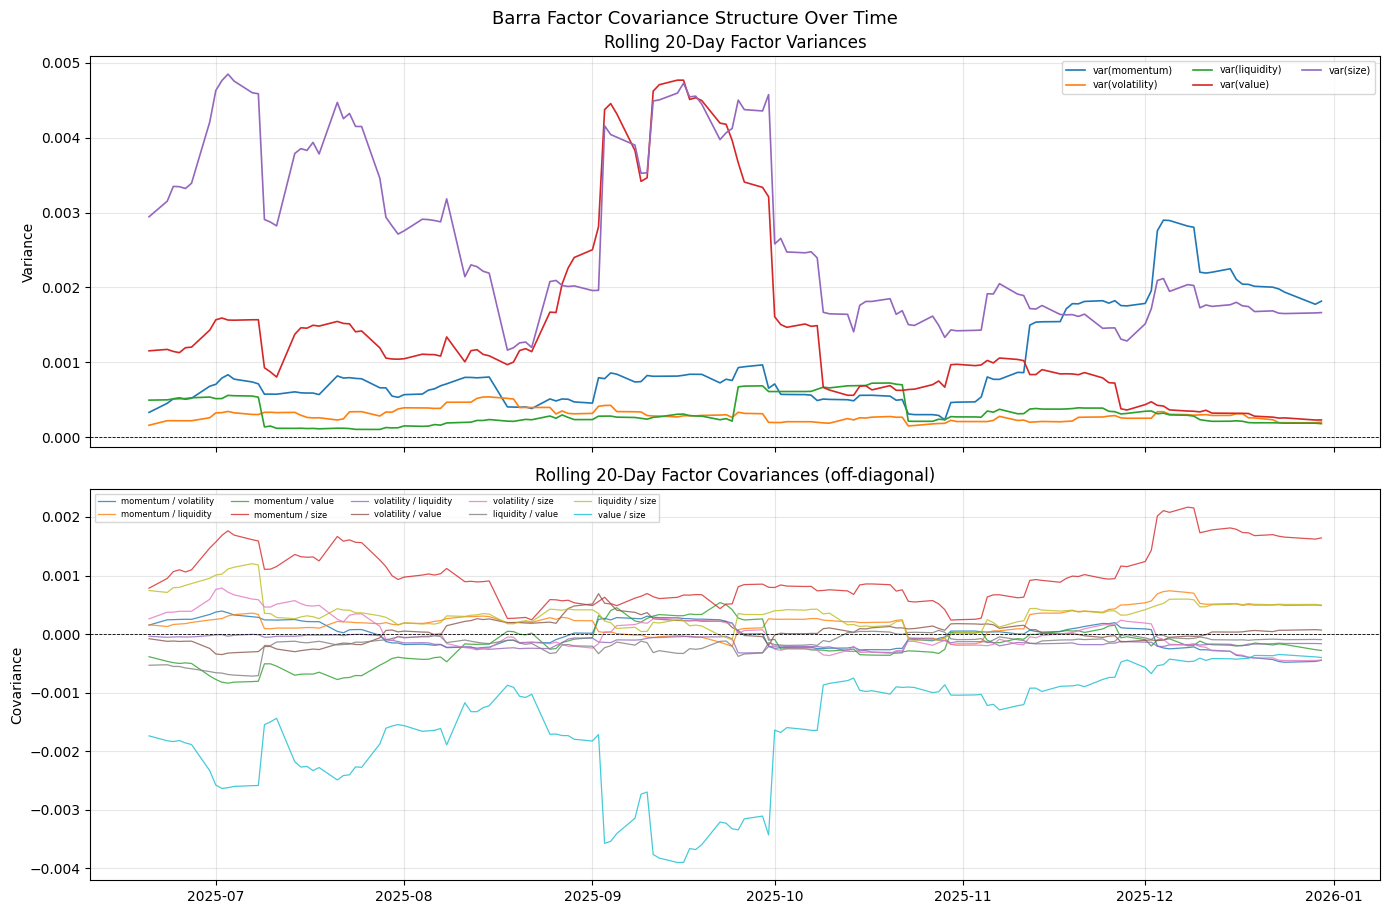

Saved: factor_covariance_rolling.png

── Beta vs Equal-Weighted Portfolio ──
AUB.AX    0.2010
LAU.AX    0.3229
VVA.AX    0.5238
WTC.AX    0.8548
COS.AX    1.0546
XYZ.AX    1.0932
TLX.AX    1.1915
DUG.AX    1.2159
ANG.AX    1.2716
PLY.AX    2.2707
Name: Beta vs EW Portfolio, dtype: float64

── Volatility Decomposition (annualised %) ──
        Total_Vol_Ann  Factor_Vol_Ann  Idio_Vol_Ann  Factor_Share  Idio_Share  \
Ticker                                                                          
ANG.AX        63.9518         59.4186       36.2940        0.8633      0.3221   
AUB.AX        35.0219        170.0180       33.8229       23.5673      0.9327   
COS.AX        62.9037         50.8531       38.8578        0.6536      0.3816   
DUG.AX        62.9940         54.3660       44.2641        0.7448      0.4937   
LAU.AX        31.1016         42.4989       31.4869        1.8672      1.0249   
PLY.AX        90.0950         72.9705       56.4046        0.6560      0.3919   
TLX.AX        5

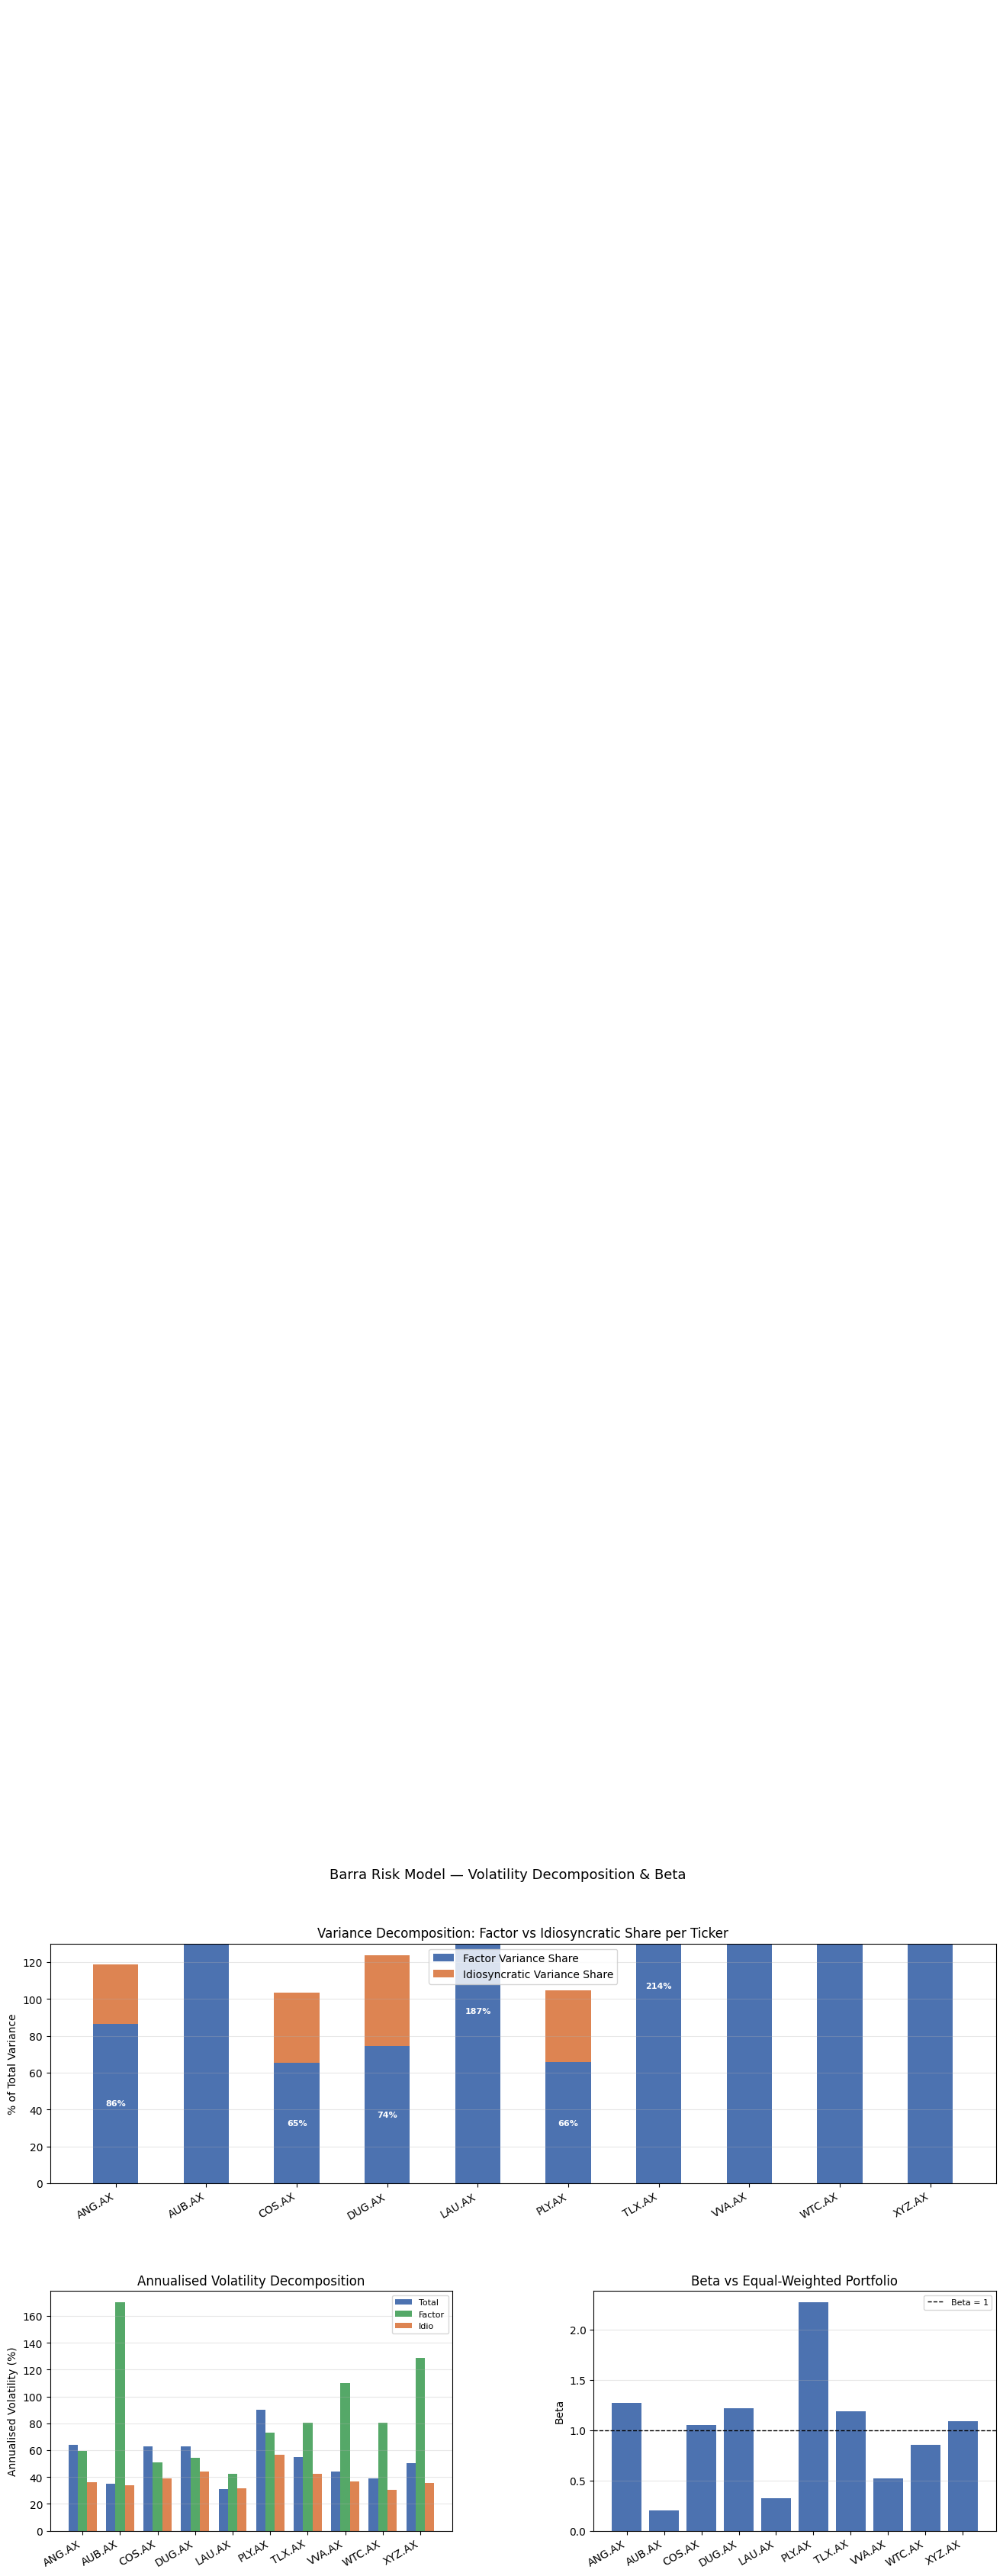

Saved: volatility_decomposition.png


In [66]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ROLL_WINDOW = 20          # rolling covariance window (trading days)
ANNUALISE   = 252         # trading days per year

factor_pairs = [(a, b) for i, a in enumerate(factor_list)
                        for b in factor_list[i:]]   # upper triangle + diagonal

rolling_cov_series = {}
for (a, b) in factor_pairs:
    label = f"{a} / {b}" if a != b else f"var({a})"
    rolling_cov_series[label] = (
        factor_returns_df[a]
        .rolling(ROLL_WINDOW)
        .cov(factor_returns_df[b])
    )

rolling_cov_df = pd.DataFrame(rolling_cov_series).dropna()

# Split into variances (diagonal) and covariances (off-diagonal) for clarity
var_cols  = [c for c in rolling_cov_df.columns if c.startswith("var(")]
cov_cols  = [c for c in rolling_cov_df.columns if not c.startswith("var(")]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for col in var_cols:
    axes[0].plot(rolling_cov_df.index, rolling_cov_df[col], label=col, linewidth=1.2)
axes[0].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[0].set_title(f"Rolling {ROLL_WINDOW}-Day Factor Variances", fontsize=12)
axes[0].set_ylabel("Variance")
axes[0].legend(fontsize=7, ncol=3)
axes[0].grid(alpha=0.3)

for col in cov_cols:
    axes[1].plot(rolling_cov_df.index, rolling_cov_df[col], label=col, linewidth=0.9, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[1].set_title(f"Rolling {ROLL_WINDOW}-Day Factor Covariances (off-diagonal)", fontsize=12)
axes[1].set_ylabel("Covariance")
axes[1].legend(fontsize=6, ncol=5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("Barra Factor Covariance Structure Over Time", fontsize=13, y=1.01)
plt.savefig("factor_covariance_rolling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: factor_covariance_rolling.png")


#  BETA RELATIVE TO EQUAL-WEIGHTED PORTFOLIO
# Equal-weighted portfolio return each day
portfolio_returns = returns_aligned.mean(axis=1)   # Series: dates

# Per-ticker beta = Cov(r_i, r_p) / Var(r_p)
port_var = portfolio_returns.var()

betas = {}
for ticker in returns.columns:
    stock_ret = returns_aligned[ticker].dropna()
    common    = stock_ret.index.intersection(portfolio_returns.index)
    cov_ip    = stock_ret.loc[common].cov(portfolio_returns.loc[common])
    betas[ticker] = cov_ip / port_var

beta_series = pd.Series(betas, name="Beta vs EW Portfolio").sort_values()
print("\n── Beta vs Equal-Weighted Portfolio ──")
print(beta_series.round(4))


#VOLATILITY DECOMPOSITION 
# Per-ticker: total vol, factor vol, idio vol (annualised %)
tickers = returns.columns.tolist()
F_mat   = factor_cov.values                                          # K × K
B_port  = exposure.loc[last_date].reindex(tickers).fillna(0).values  # N × K

# Factor variance per ticker: diag(B @ F @ B')
factor_var_per_ticker = np.diag(B_port @ F_mat @ B_port.T)          # N

# Idiosyncratic variance per ticker (already computed)
idio_var_vec = idio_var.reindex(tickers).fillna(0).values            # N

# Total variance per ticker (from actual returns — ground truth)
total_var_vec = returns_aligned.var().reindex(tickers).fillna(0).values  # N

decomp = pd.DataFrame({
    "Ticker":         tickers,
    "Total_Var":      total_var_vec,
    "Factor_Var":     factor_var_per_ticker,
    "Idio_Var":       idio_var_vec,
    "Total_Vol_Ann":  np.sqrt(total_var_vec  * ANNUALISE) * 100,
    "Factor_Vol_Ann": np.sqrt(factor_var_per_ticker * ANNUALISE) * 100,
    "Idio_Vol_Ann":   np.sqrt(idio_var_vec   * ANNUALISE) * 100,
    "Factor_Share":   np.where(total_var_vec > 0,
                               factor_var_per_ticker / total_var_vec, np.nan),
    "Idio_Share":     np.where(total_var_vec > 0,
                               idio_var_vec / total_var_vec, np.nan),
    "Beta":           beta_series.reindex(tickers).values,
}).set_index("Ticker")

print("\n── Volatility Decomposition (annualised %) ──")
print(decomp[["Total_Vol_Ann","Factor_Vol_Ann","Idio_Vol_Ann",
              "Factor_Share","Idio_Share","Beta"]].round(4))


#Bar charts: variance contributions + annualised vols
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

#  Stacked bar: variance shares 
ax1 = fig.add_subplot(gs[0, :])   # full top row
x   = np.arange(len(tickers))
w   = 0.5

bars_factor = ax1.bar(x, decomp["Factor_Share"] * 100, w,
                      label="Factor Variance Share", color="#4C72B0")
bars_idio   = ax1.bar(x, decomp["Idio_Share"] * 100, w,
                      bottom=decomp["Factor_Share"] * 100,
                      label="Idiosyncratic Variance Share", color="#DD8452")

ax1.set_xticks(x)
ax1.set_xticklabels(tickers, rotation=30, ha="right")
ax1.set_ylabel("% of Total Variance")
ax1.set_title("Variance Decomposition: Factor vs Idiosyncratic Share per Ticker")
ax1.legend()
ax1.set_ylim(0, 130)
ax1.grid(axis="y", alpha=0.3)

# Annotate each bar with factor share %
for i, v in enumerate(decomp["Factor_Share"].fillna(0)):
    ax1.text(i, v * 100 / 2, f"{v*100:.0f}%",
             ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Annualised vols grouped bar 
ax2 = fig.add_subplot(gs[1, 0])
bw  = 0.25
ax2.bar(x - bw, decomp["Total_Vol_Ann"],  bw, label="Total",  color="#4C72B0")
ax2.bar(x,      decomp["Factor_Vol_Ann"], bw, label="Factor", color="#55A868")
ax2.bar(x + bw, decomp["Idio_Vol_Ann"],   bw, label="Idio",   color="#DD8452")
ax2.set_xticks(x)
ax2.set_xticklabels(tickers, rotation=30, ha="right")
ax2.set_ylabel("Annualised Volatility (%)")
ax2.set_title("Annualised Volatility Decomposition")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

# Beta bar chart 
ax3 = fig.add_subplot(gs[1, 1])
colors = ["#4C72B0" if b >= 0 else "#C44E52" for b in decomp["Beta"].fillna(0)]
ax3.bar(x, decomp["Beta"].fillna(0), color=colors)
ax3.axhline(1.0, color="black", linewidth=1, linestyle="--", label="Beta = 1")
ax3.axhline(0.0, color="grey",  linewidth=0.6, linestyle=":")
ax3.set_xticks(x)
ax3.set_xticklabels(tickers, rotation=30, ha="right")
ax3.set_ylabel("Beta")
ax3.set_title("Beta vs Equal-Weighted Portfolio")
ax3.legend(fontsize=8)
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("Barra Risk Model — Volatility Decomposition & Beta", fontsize=13)
plt.savefig("volatility_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: volatility_decomposition.png")

In [ ]:
#Vsualisation:
print("Factor Returns:")
factor_returns.plot(figsize=(10,6), title="Factor Returns Over Time")
plt.show()
print("Factor Volatility:")
factor_vols.plot(kind="bar", title="Factor Volatility")
plt.show()
print("Idiosyncratic Volatility:")
idiosyncratic_vols.plot(kind="bar", title="Idiosyncratic Volatility")
plt.show()

#R2 over time map:
plt.figure(figsize=(10,5))
R2.plot(title="R² Over Time")
plt.ylabel("R²")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# momentum factor exposures heatmap
plt.figure(figsize=(12,6))
sns.heatmap(factors.xs("momentum", axis=1, level=0).T, cmap="coolwarm", center=0)
plt.title("Momentum Factor Exposures Across Stocks")
plt.ylabel("Stock")
plt.xlabel("Date")
plt.show()

#correlation between factors heatmap:
print("Correlation between factors:")
R2.plot(title = "Factor return correltion")
factor_returns.corr()
sns.heatmap(factor_returns.corr(), annot=True, cmap="coolwarm")
plt.show()


# calcualte covariance matrix for both stock and factor returns
# Try find value from size factor inversely proportional

#graph volatility over time factor vol, total vo and specific vol
